# Análisis Exploratorio de Datos (EDA)
## Minería de Datos



## Objetivos
- Comprender el propósito del EDA.
- Detectar problemas de calidad de datos.
- Interpretar distribuciones y relaciones.
- Formular hipótesis de negocio o investigación.
- Aplicar EDA al proyecto de cada grupo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(8,4)

## Discusión inicial

Pregunta al curso: **¿Qué podría salir mal si entrenamos un modelo sin conocer los datos?**

## Las 5 preguntas del EDA
1. ¿Qué datos tengo?
2. ¿Hay datos faltantes?
3. ¿Existen valores atípicos?
4. ¿Cómo se distribuyen los datos?
5. ¿Qué relaciones existen entre variables?

## Ejemplo guiado: Rendimiento académico

In [3]:
df=pd.DataFrame({
"Estudiante":["A","B","C","D"],
"Horas_Estudio":[2,5,8,10],
"Asistencia":[60,75,85,95],
"Nota":[45,60,80,92]
})
df

,Estudiante,Horas_Estudio,Asistencia,Nota
0,A,2,60,45
1,B,5,75,60
2,C,8,85,80
3,D,10,95,92


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Estudiante     4 non-null      str  
 1   Horas_Estudio  4 non-null      int64
 2   Asistencia     4 non-null      int64
 3   Nota           4 non-null      int64
dtypes: int64(3), str(1)
memory usage: 260.0 bytes


In [5]:
df.describe()

,Horas_Estudio,Asistencia,Nota
count,4.00,4.000000,4.000000
mean,6.25,78.750000,69.250000
std,3.50,14.930394,20.870633
min,2.00,60.000000,45.000000
25%,4.25,71.250000,56.250000
50%,6.50,80.000000,70.000000
75%,8.50,87.500000,83.000000
max,10.00,95.000000,92.000000


### Pregunta 
¿Qué observaciones pueden realizar únicamente observando la tabla?

## Datos faltantes

In [6]:
faltantes=pd.DataFrame({
"Edad":[25,np.nan,27,30],
"Ingreso":[500,600,np.nan,850]
})

faltantes

,Edad,Ingreso
0,25.0,500.0
1,NaN,600.0
2,27.0,NaN
3,30.0,850.0


In [7]:
faltantes.isnull().sum()

Edad       1
Ingreso    1
dtype: int64

### Reflexión
¿Eliminarías los registros o imputarías los valores?

## Datos duplicados

In [8]:
duplicados=pd.DataFrame({
"ID":[1,2,2,3],
"Nombre":["Ana","Juan","Juan","Luis"]
})

duplicados

,ID,Nombre
0,1,Ana
1,2,Juan
2,2,Juan
3,3,Luis


In [9]:
duplicados.duplicated().sum()

np.int64(1)

## Valores atípicos (Outliers)

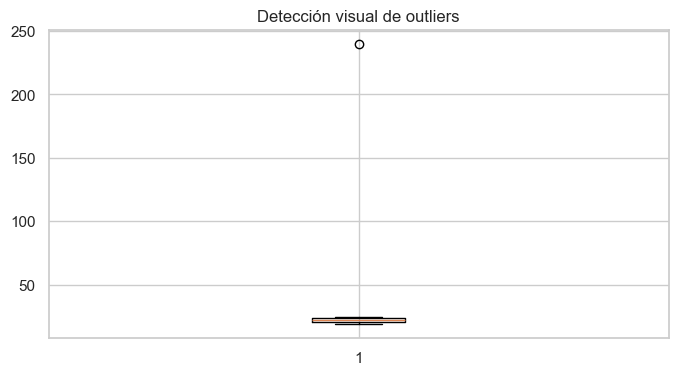

In [10]:
edades=[19,20,21,22,23,24,240]
plt.boxplot(edades)
plt.title("Detección visual de outliers")
plt.show()

In [11]:
s=pd.Series(edades)
Q1=s.quantile(0.25)
Q3=s.quantile(0.75)
IQR=Q3-Q1
out=s[(s<Q1-1.5*IQR)|(s>Q3+1.5*IQR)]
out

6    240
dtype: int64

### Pregunta
¿El valor atípico es un error o una observación válida?

## Distribuciones

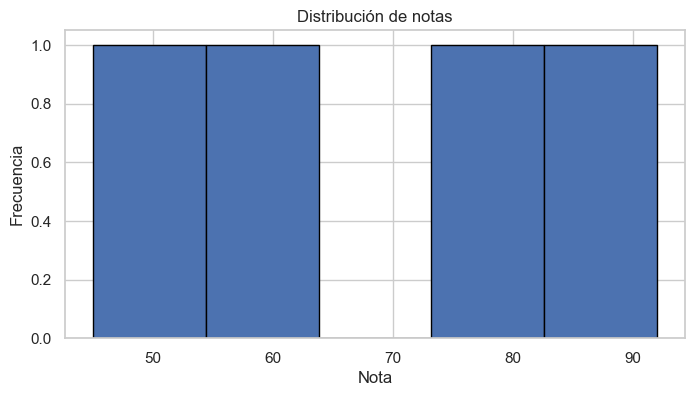

In [12]:
plt.hist(df["Nota"],bins=5,edgecolor="black")
plt.title("Distribución de notas")
plt.xlabel("Nota")
plt.ylabel("Frecuencia")
plt.show()

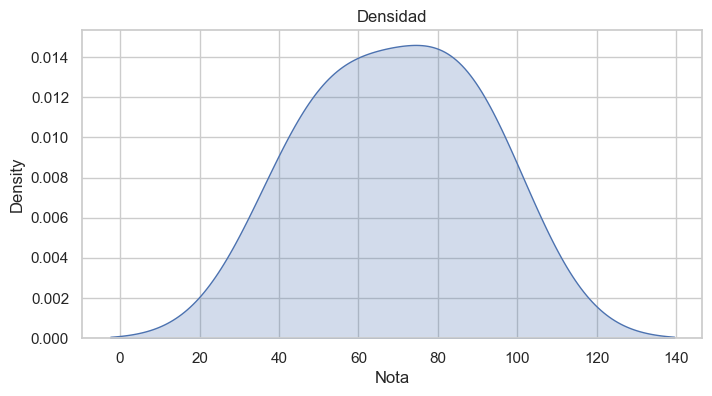

In [13]:
sns.kdeplot(df["Nota"],fill=True)
plt.title("Densidad")
plt.show()

## Relación entre variables

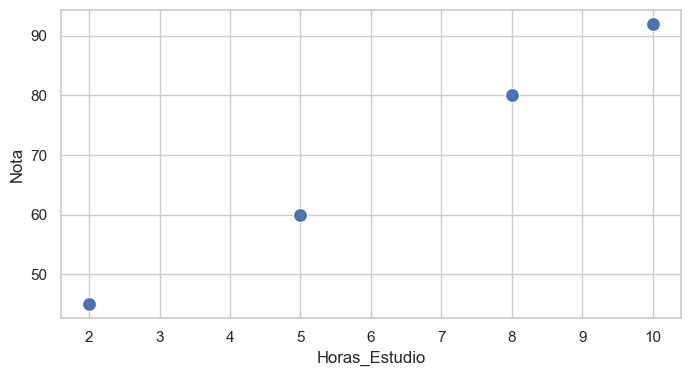

In [14]:
sns.scatterplot(data=df,x="Horas_Estudio",y="Nota",s=100)
plt.show()

In [15]:
df[["Horas_Estudio","Asistencia","Nota"]].corr(numeric_only=True)

,Horas_Estudio,Asistencia,Nota
Horas_Estudio,1.000000,0.996689,0.998213
Asistencia,0.996689,1.000000,0.990832
Nota,0.998213,0.990832,1.000000


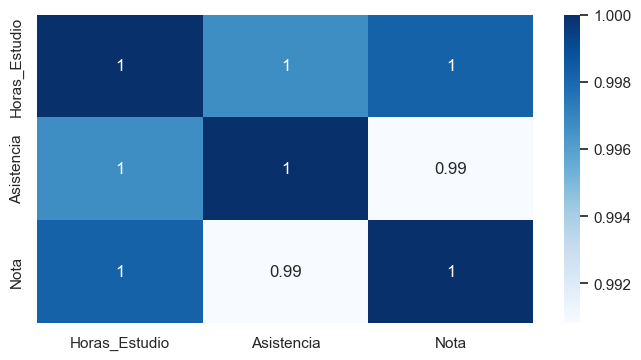

In [16]:
sns.heatmap(df[["Horas_Estudio","Asistencia","Nota"]].corr(numeric_only=True),annot=True,cmap="Blues")
plt.show()

## Dataset sintético más realista

In [17]:
np.random.seed(42)
n=200
proyecto=pd.DataFrame({
"Tiempo_Sitio":np.random.normal(40,10,n),
"Paginas":np.random.normal(12,3,n),
"Compras":np.random.normal(5,1.5,n),
"Monto":np.random.normal(80,20,n)
})
proyecto.head()

,Tiempo_Sitio,Paginas,Compras,Monto
0,44.967142,13.073362,2.608359,95.139772
1,38.617357,13.682354,4.100937,61.556694
2,46.476885,15.249154,5.007866,97.392118
3,55.230299,15.161406,5.070471,107.112757
4,37.658466,7.866992,4.324902,88.268698


In [19]:
proyecto.describe()

,Tiempo_Sitio,Paginas,Compras,Monto
count,200.000000,200.000000,200.000000,200.000000
mean,39.592290,12.257605,4.871517,80.179333
std,9.310039,2.961011,1.491063,20.391487
min,13.802549,2.276198,1.292533,26.062267
25%,32.948723,10.182487,3.809182,65.870616
50%,39.958081,12.236518,4.883600,80.445250
75%,45.008525,14.061693,5.858132,93.703542
max,67.201692,23.558194,9.618321,132.647641


In [20]:
proyecto.isnull().sum()

Tiempo_Sitio    0
Paginas         0
Compras         0
Monto           0
dtype: int64

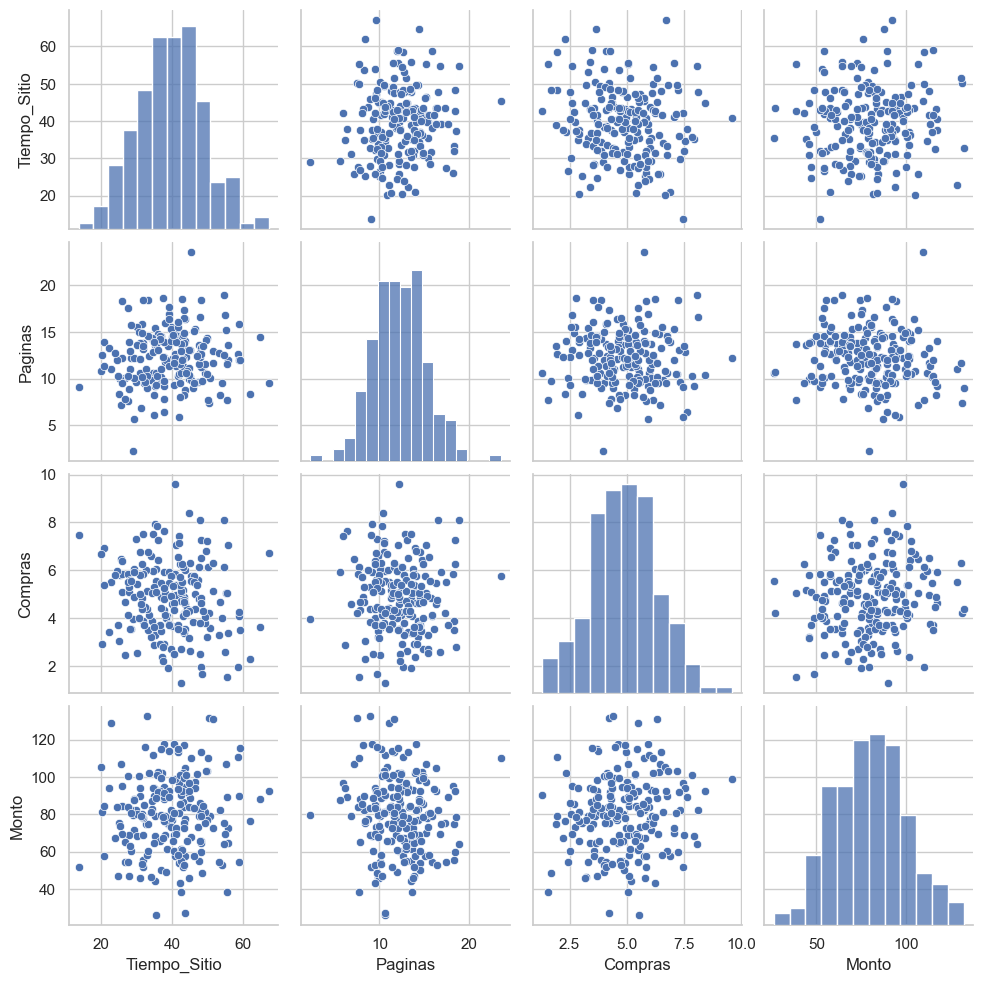

In [21]:
sns.pairplot(proyecto)
plt.show()

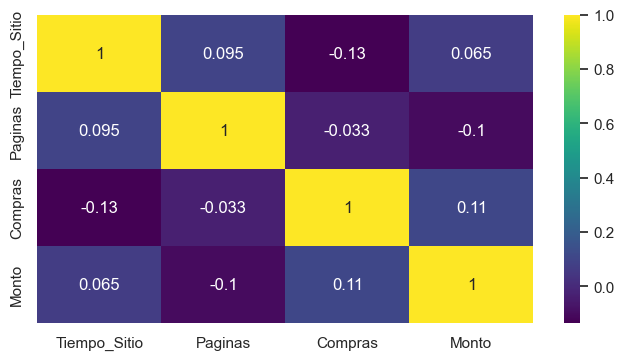

In [22]:
sns.heatmap(proyecto.corr(numeric_only=True),annot=True,cmap="viridis")
plt.show()

## Actividad: Detectives de Datos

Cada grupo debe analizar su propio conjunto de datos.

### Misión 1
- Número de registros
- Número de variables
- Tipos de datos

### Misión 2
- Faltantes
- Duplicados
- Inconsistencias

### Misión 3
- Un outlier
- Una distribución interesante
- Una relación relevante

### Misión 4
Hipótesis:

"Creemos que ____ influye en ____ porque observamos ____"

In [ ]:
# PLANTILLA PARA LOS PROYECTOS
# df = pd.read_csv("datos.csv")
# df.head()
# df.info()
# df.describe()
# df.isnull().sum()
# df.duplicated().sum()

In [ ]:
# Variables numéricas
# sns.pairplot(df.select_dtypes(include="number"))
# plt.show()

In [ ]:
# Correlaciones
# sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
# plt.show()

## Mini Evaluación

1. ¿Qué información brinda un boxplot?
2. ¿Qué significa una correlación cercana a 1?
3. ¿Qué hacer cuando existen valores faltantes?
4. ¿Por qué el EDA se realiza antes del modelado?

## Competencia Final

Cada equipo tiene 30 segundos para presentar el hallazgo más interesante encontrado en sus datos.

> Si no entiendes tus datos, no entiendes tu problema.